In [ ]:
# ── Dependencias e Importaciones ─────────────────────────────────────────────
!pip install gymnasium imageio --quiet

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import random
import imageio
from IPython.display import clear_output, Image, display
import warnings

warnings.filterwarnings("ignore")

# ── Reproducibilidad ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## 1. El entorno: Taxi-v3

A diferencia de entornos más simples de navegación pura, **Taxi-v3** requiere que el agente aprenda una secuencia lógica de tareas.

* **Estados (500):** El espacio de estados combina la posición del taxi (5x5), las 5 ubicaciones posibles del pasajero (4 paradas + dentro del taxi) y los 4 destinos posibles.
* **Acciones (6):** `0: Sur`, `1: Norte`, `2: Este`, `3: Oeste`, `4: Recoger (Pickup)`, `5: Dejar (Dropoff)`.
* **Recompensas:** * -1 por cada paso (incentiva a ser rápido).
    * +20 por dejar al pasajero en el destino correcto.
    * -10 por intentar recoger o dejar al pasajero en un lugar incorrecto.

## 2. El algoritmo Q-Learning (Off-Policy)

A diferencia de SARSA, **Q-Learning** es un método *Off-Policy*. Esto significa que la política que se evalúa y mejora (la política objetivo) es diferente de la política que se utiliza para tomar decisiones e interactuar con el entorno (la política de comportamiento).

La regla de actualización utiliza el operador máximo ($\max$) sobre el siguiente estado, asumiendo una explotación pura (comportamiento codicioso), independientemente de lo que el agente decida hacer realmente a continuación:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \right]$$

Donde $\alpha$ es la tasa de aprendizaje y $\gamma$ es el factor de descuento.

In [ ]:
def choose_action(state, Q_table, epsilon, env):
    """Política Epsilon-Greedy para seleccionar acciones"""
    if random.uniform(0, 1) < epsilon:
        return env.action_space.sample() # Exploración
    else:
        return np.argmax(Q_table[state, :]) # Explotación

def train_qlearning(env, episodes, alpha, gamma, epsilon_start, epsilon_decay, epsilon_min):
    """Bucle principal de entrenamiento Q-Learning"""
    Q_table = np.zeros((env.observation_space.n, env.action_space.n))
    stats_rewards = []
    stats_lengths = []

    epsilon = epsilon_start

    for ep in range(episodes):
        state, _ = env.reset()

        total_reward = 0
        steps = 0
        done = False

        while not done:
            # Seleccionamos acción usando la política de comportamiento (Epsilon-Greedy)
            action = choose_action(state, Q_table, epsilon, env)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Q-LEARNING: Actualización usando el MAX del siguiente estado (Off-Policy)
            best_next_action = np.argmax(Q_table[next_state, :])
            td_target = reward + gamma * Q_table[next_state, best_next_action] * (not done)

            td_error = td_target - Q_table[state, action]
            Q_table[state, action] += alpha * td_error

            state = next_state
            total_reward += reward
            steps += 1

        # Decaimiento de epsilon al final del episodio
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        stats_rewards.append(total_reward)
        stats_lengths.append(steps)

    return Q_table, stats_rewards, stats_lengths

## 3. Entrenamiento y Evaluación

Entrenaremos al agente bajo dos regímenes de exploración distintos para observar cómo la convergencia de Q-Learning se ve afectada en un entorno de 500 estados:
1.  **Exploración Lenta (Configuración A):** El agente mantiene una alta aleatoriedad durante más episodios.
2.  **Exploración Rápida (Configuración B):** El agente decae su epsilon muy rápido, pasando pronto a la explotación de lo aprendido.

In [ ]:
env = gym.make("Taxi-v3")
n_episodes = 3000

print("Entrenando Q-Learning - Configuración A (Exploración Lenta)...")
Q_A, stats_A, len_A = train_qlearning(
    env, episodes=n_episodes, alpha=0.1, gamma=0.99,
    epsilon_start=1.0, epsilon_decay=0.999, epsilon_min=0.01
)

print("Entrenando Q-Learning - Configuración B (Exploración Rápida)...")
Q_B, stats_B, len_B = train_qlearning(
    env, episodes=n_episodes, alpha=0.1, gamma=0.99,
    epsilon_start=1.0, epsilon_decay=0.99, epsilon_min=0.01
)

env.close()
print("¡Entrenamientos finalizados!")

Entrenando Q-Learning - Configuración A (Exploración Lenta)...
Entrenando Q-Learning - Configuración B (Exploración Rápida)...
¡Entrenamientos finalizados!


In [ ]:
# Guardamos los resultados para análisis comparativo futuro
with open("stats_A_QL.pkl", "wb") as f:
    pickle.dump(stats_A, f)

with open("len_A_QL.pkl", "wb") as f:
    pickle.dump(len_A, f)

with open("stats_B_QL.pkl", "wb") as f:
    pickle.dump(stats_B, f)

with open("len_B_QL.pkl", "wb") as f:
    pickle.dump(len_B, f)

print("Archivos .pkl guardados correctamente.")

Archivos .pkl guardados correctamente.


## 4. Visualización del Aprendizaje: Recompensa y Longitud de Episodios

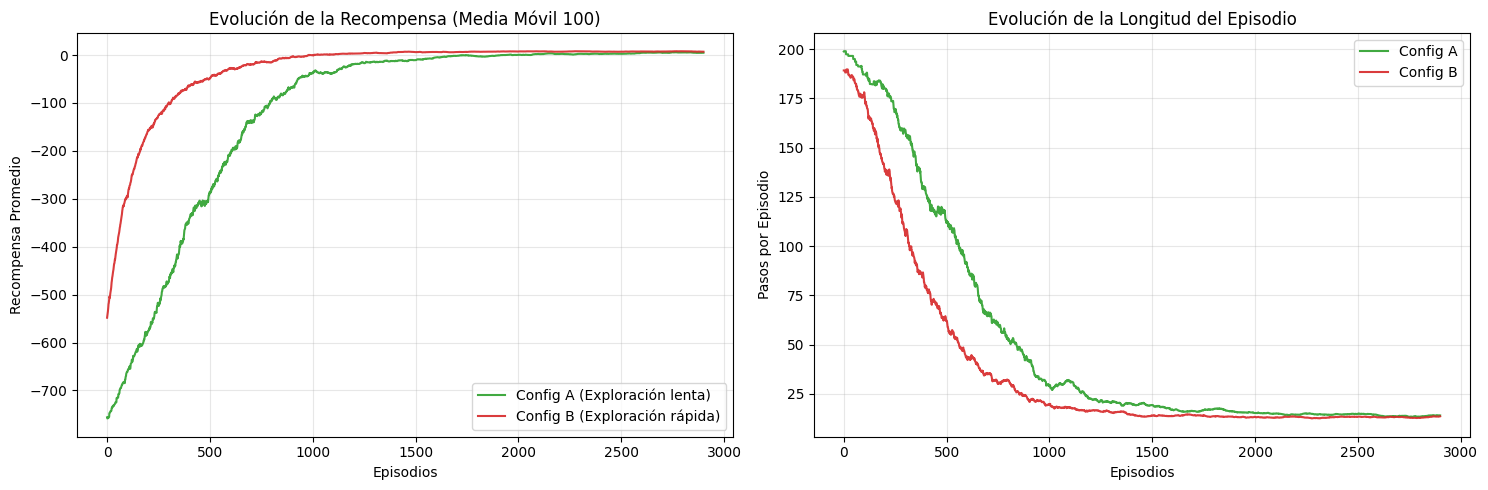

In [ ]:
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Recompensas
axs[0].plot(moving_average(stats_A, 100), label="Config A (Exploración lenta)", color="#2ca02c", alpha=0.9)
axs[0].plot(moving_average(stats_B, 100), label="Config B (Exploración rápida)", color="#d62728", alpha=0.9)
axs[0].set_xlabel("Episodios")
axs[0].set_ylabel("Recompensa Promedio")
axs[0].set_title("Evolución de la Recompensa (Media Móvil 100)")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Gráfica 2: Longitud de los episodios (Pasos)
axs[1].plot(moving_average(len_A, 100), label="Config A", color="#2ca02c", alpha=0.9)
axs[1].plot(moving_average(len_B, 100), label="Config B", color="#d62728", alpha=0.9)
axs[1].set_xlabel("Episodios")
axs[1].set_ylabel("Pasos por Episodio")
axs[1].set_title("Evolución de la Longitud del Episodio")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### ¿Por qué la gráfica $f(t) = len(episodio_t)$ es un buen indicador de aprendizaje?
Tal y como se solicita en los requisitos de la práctica, hemos incluido la evolución temporal de la longitud del episodio (pasos por episodio). Esta métrica es un indicador de aprendizaje excelente por dos motivos:
1. **Eficiencia de la ruta:** En *Taxi-v3*, cada movimiento penaliza con -1. La única forma de maximizar la recompensa es minimizando los pasos. La curva de longitud demuestra visualmente cómo el agente deja de deambular aleatoriamente y traza la ruta geodésica más corta hacia su objetivo.
2. **Aislamiento del ruido:** La recompensa total sufre grandes varianzas (+20 al finalizar, -10 por error). La métrica de pasos, sin embargo, decrece de forma mucho más suave, permitiendo diagnosticar con precisión matemática en qué episodio el algoritmo Q-Learning converge hacia la política óptima.

## 5. Análisis Espacial: Heatmap y Learned Q-Values
Extraeremos la política de la **Configuración B**, evaluando el caso donde el **pasajero está en la posición 0 (Rojo)** y quiere ir al **destino 1 (Verde)**.

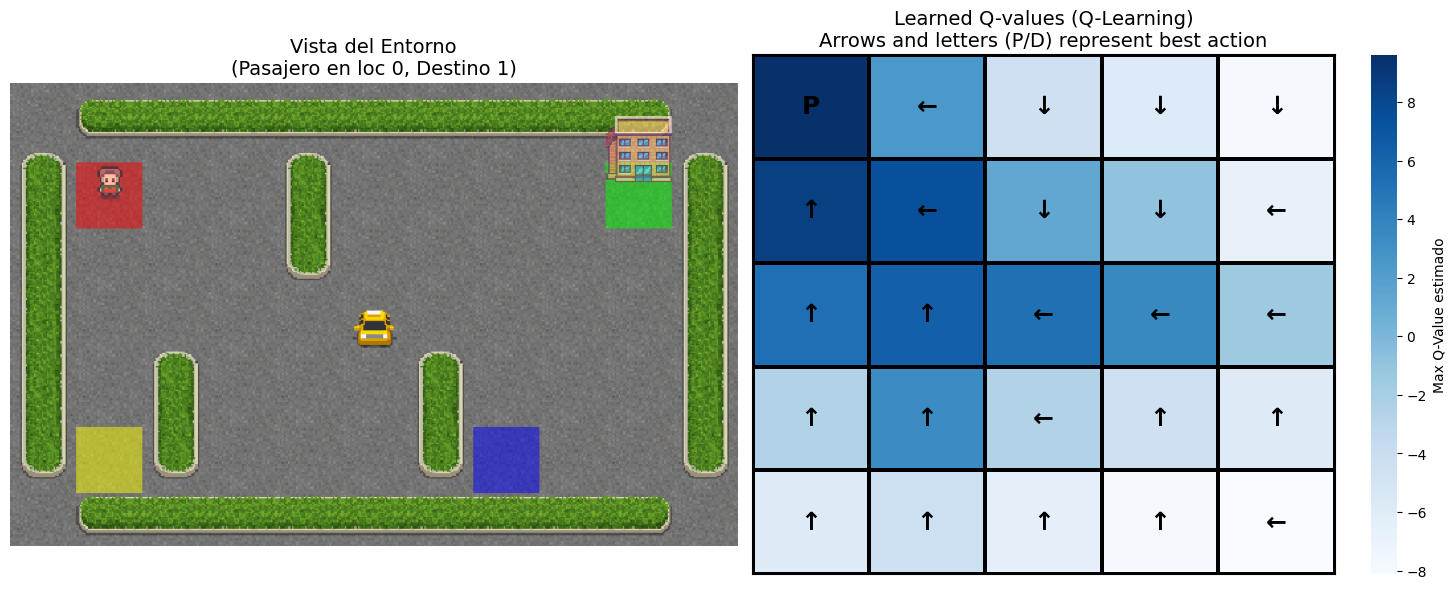

In [ ]:
def get_taxi_qtable_directions(qtable, env, pass_idx=0, dest_idx=1):
    q_max_grid = np.zeros((5, 5))
    directions_grid = np.empty((5, 5), dtype=object)

    action_symbols = {0: '↓', 1: '↑', 2: '→', 3: '←', 4: 'P', 5: 'D'}

    for row in range(5):
        for col in range(5):
            state = env.unwrapped.encode(row, col, pass_idx, dest_idx)
            best_action = int(np.argmax(qtable[state]))
            q_max_grid[row, col] = np.max(qtable[state])
            directions_grid[row, col] = action_symbols[best_action]

    return q_max_grid, directions_grid

def plot_taxi_q_values_map(qtable, env_name="Taxi-v3", pass_idx=0, dest_idx=1):
    env_render = gym.make(env_name, render_mode="rgb_array")
    env_render.reset()

    # Forzamos estado visual
    state_for_render = env_render.unwrapped.encode(2, 2, pass_idx, dest_idx)
    env_render.unwrapped.s = state_for_render
    img = env_render.render()
    env_render.close()

    q_max_grid, directions_grid = get_taxi_qtable_directions(qtable, env_render, pass_idx, dest_idx)

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

    ax[0].imshow(img)
    ax[0].axis("off")
    ax[0].set_title(f"Vista del Entorno\n(Pasajero en loc {pass_idx}, Destino {dest_idx})", fontsize=14)

    sns.heatmap(
        q_max_grid,
        annot=directions_grid,
        fmt="",
        ax=ax[1],
        cmap=sns.color_palette("Blues", as_cmap=True),
        linewidths=1.5,
        linecolor="black",
        xticklabels=[],
        yticklabels=[],
        cbar_kws={'label': 'Max Q-Value estimado'},
        annot_kws={"fontsize": 18, "weight": "bold", "color": "black"},
    )
    ax[1].set_title("Learned Q-values (Q-Learning)\nArrows and letters (P/D) represent best action", fontsize=14)

    for _, spine in ax[1].spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color("black")

    plt.tight_layout()
    plt.show()

# Ejecutamos la gráfica para nuestra tabla Q_B
plot_taxi_q_values_map(Q_B, pass_idx=0, dest_idx=1)

## 6. Comprobación Visual (GIF)
Por último, renderizamos un episodio utilizando la tabla Q aprendida para verificar cualitativamente el éxito del entrenamiento.

Episodio finalizado en 18 pasos. GIF guardado en: taxi_qlearning_config_B.gif


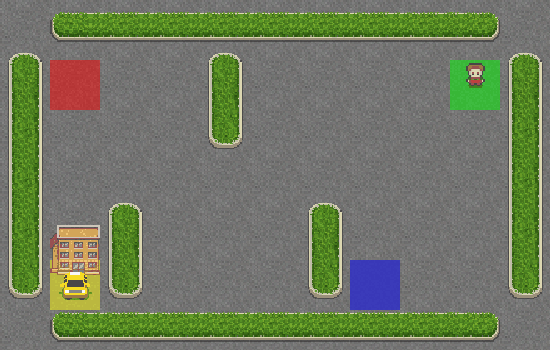

In [ ]:
def play_and_record(env_name, Q_table, filename, max_steps=50):
    env_render = gym.make(env_name, render_mode="rgb_array")
    state, _ = env_render.reset()

    frames = []
    done = False
    step = 0
    frames.append(env_render.render())

    while not done and step < max_steps:
        action = np.argmax(Q_table[state, :]) # Explotación pura
        next_state, reward, terminated, truncated, _ = env_render.step(action)
        done = terminated or truncated

        frames.append(env_render.render())
        state = next_state
        step += 1

    env_render.close()
    imageio.mimsave(filename, frames, fps=5)
    print(f"Episodio finalizado en {step} pasos. GIF guardado en: {filename}")

# Grabamos y mostramos la configuración rápida (B)
gif_path_ql = "taxi_qlearning_config_B.gif"
play_and_record("Taxi-v3", Q_B, gif_path_ql)
display(Image(open(gif_path_ql, 'rb').read()))